# Heat risk triage — data, model and evaluation

The analytical record behind the pipeline. Every figure here is computed by
importing the pipeline modules; nothing is reimplemented, because logic that
exists only in a notebook drifts out of step with the scripts and cannot be
trusted. The scripts are the source of truth.

Run order before this notebook: `generate_data.py`, `extract.py`, `model.py`,
`retrieve.py`, `validate.py`.

In [1]:
%matplotlib inline

import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")

import config
import extract
import features
import model
import validate

pd.set_option("display.width", 120)
print(f"fleet: {config.N_ASSETS} assets, {config.N_HISTORICAL_EVENTS} historical events")
print(f"extraction model: {config.EXTRACTION_MODEL}")

fleet: 900 assets, 16 historical events
extraction model: gemini-3.5-flash-lite


## 1. Data generation

`generate_data.py` writes the fleet, the weather, the hidden failure process and
the inspection notes, then asserts six hard gates and writes the measured value
of each to `output/data_checks.txt`. A gate failure stops the build rather than
being worked around.

The gates exist to stop the synthetic world being either implausible or too easy:
gate 2 is the project's central premise, gate 4 keeps mild events near
failure-free, and gate 6 stops the failure label being a deterministic read-off
of hidden condition.

In [2]:
print((config.OUTPUT_DIR / "data_checks.txt").read_text())

Hard gates on generated data
ageing reference temperature in force: 38.0 C

[PASS] 1. realised failure rate
         measured: 0.0096
         required in [0.008, 0.013]
[PASS] 2. long-moderate stress exceeds short-severe
         measured: long-moderate 2.56 vs short-severe 1.57 equivalent days
         long-moderate must be strictly greater (equivalent days at reference)
[PASS] 3. non-zero stress share on heat events
         measured: 0.9962
         required >= 0.8
[PASS] 4. mild event failure rate
         measured: 0.0015
         required < 0.002
[PASS] 5. degree-hours vs peak temperature correlation
         measured: 0.4961
         required < 0.85
[PASS] 6. failures in below-median condition assets
         measured: 0.2609 (36 of 138 failures)
         required >= 0.2



In [3]:
assets = features.load_assets()
events = features.load_events()
hourly = features.load_hourly()
outcomes = features.load_outcomes()
inspections = features.load_inspections()

historical = events[~events["is_scenario"]]
print(f"training rows: {len(outcomes):,}  failures: {outcomes['failed'].sum():,}"
      f"  base rate: {outcomes['failed'].mean():.4f}")
print(f"inspection notes: {len(inspections):,}")
assets.head()

training rows: 14,400  failures: 138  base rate: 0.0096
inspection notes: 1,800


,asset_id,name,district,lat,lon,install_year,rated_capacity_mva,cooling_type,peak_load_pct,customers_served,criticality,last_maintenance_date,prior_heat_faults
0,SUB-SGW-001,Camden Landing 69/12kV,Northfield,38.8089,-121.3358,1987,10,OFAF,0.686,1117,2,2024-12-13,1
1,SUB-SGW-002,Marlow Bend 69/12kV,Cedar Basin,38.4586,-121.2250,1979,10,ONAF,0.762,679,5,2025-05-24,1
2,SUB-SGW-003,Zeller Vale 69/12kV,Ridgeline,38.4883,-121.5521,1978,10,ONAF,0.633,1076,3,2025-05-02,0
3,SUB-SGW-004,Granite Bluff 69/12kV,Junction West,38.6442,-121.6820,1978,10,ONAF,0.763,990,2,2025-09-07,0
4,SUB-SGW-005,Westmarch Grove 230/34kV,Northfield,38.7607,-121.3970,2001,100,ONAN,0.570,2565,3,2024-03-17,0


## 2. Exploratory analysis

The premise the whole project rests on is that accumulated exposure matters more
than peak temperature. The first plot is the test of it: long moderate events
peak lower than short severe ones and still do more damage.

Note what the model is *not* given. It sees ambient temperature, the asset
register and the four extracted flags. It never sees core temperature, the
thermal time constant, or the latent condition that actually generated the
outcomes.

In [4]:
by_event = (outcomes.merge(events[["event_id", "event_type", "peak_temp_c", "duration_days"]],
                           on="event_id")
            .groupby(["event_id", "event_type", "peak_temp_c", "duration_days"], as_index=False)
            .agg(failures=("failed", "sum"), rate=("failed", "mean")))
by_event.sort_values("failures", ascending=False)

,event_id,event_type,peak_temp_c,duration_days,failures,rate
1,EVT-02,long-severe,40.79,5,43,0.047778
9,EVT-10,long-severe,39.09,5,27,0.030000
6,EVT-07,long-severe,39.39,5,24,0.026667
2,EVT-03,long-moderate,36.85,6,12,0.013333
11,EVT-12,long-moderate,36.66,5,8,0.008889
4,EVT-05,long-moderate,36.65,5,6,0.006667
14,EVT-15,long-moderate,35.71,5,5,0.005556
13,EVT-14,short-severe,40.26,2,4,0.004444
3,EVT-04,short-severe,41.55,2,3,0.003333
0,EVT-01,mild,30.11,3,2,0.002222


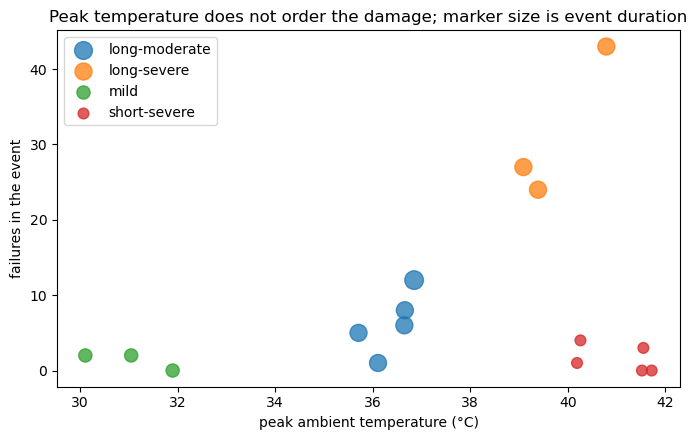

In [5]:
# Peak temperature against failures, marker size by duration. If peak alone
# drove risk, the short-severe points on the right would sit highest.
fig, ax = plt.subplots(figsize=(7, 4.5))
for event_type, group in by_event.groupby("event_type"):
    ax.scatter(group["peak_temp_c"], group["failures"],
               s=group["duration_days"] * 30, label=event_type, alpha=0.75)
ax.set_xlabel("peak ambient temperature (°C)")
ax.set_ylabel("failures in the event")
ax.set_title("Peak temperature does not order the damage; marker size is event duration")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
summary = by_event.groupby("event_type").agg(
    events=("event_id", "count"),
    mean_peak=("peak_temp_c", "mean"),
    mean_days=("duration_days", "mean"),
    failures=("failures", "sum"),
    rate=("rate", "mean"),
).sort_values("mean_peak")
print(summary.round(4))
print()
print("Short-severe events peak highest and cause fewest failures per event;")
print("long-moderate events peak lower and cause more. That is the premise.")

               events  mean_peak  mean_days  failures    rate
event_type                                                   
mild                3    31.0200        3.0         4  0.0015
long-moderate       5    36.3960        5.2        32  0.0071
long-severe         3    39.7567        5.0        94  0.0348
short-severe        5    41.0480        2.0         8  0.0018

Short-severe events peak highest and cause fewest failures per event;
long-moderate events peak lower and cause more. That is the premise.


### Why: overnight recovery sets the floor, not a failure to reset

Oil temperature lags ambient by a few hours. Over an eight-hour night a unit
sheds most of its offset — at the fast end of the modelled range, 96% of it. It
substantially *does* reset. What the overnight minimum sets is the floor it
resets to: a night at 27°C rather than 18°C starts the next day nine degrees
hotter, so each day reaches a higher peak from a higher base.

Because insulation ageing is Arrhenius and irreversible, five days of elevated
temperature does five days of damage that the weather breaking does not return.
That is why `thermal_stress` is accumulated equivalent ageing, and why
`max_overnight_min_c` and `consecutive_warm_nights` are features.

In [7]:
for tau in [config.TAU_MIN_HOURS, config.TAU_MEAN_HOURS, config.TAU_MAX_HOURS]:
    remaining = (1 - 1 / tau) ** 8
    print(f"tau {tau:.0f} h: {remaining:6.3f} of the offset remains after 8 h "
          f"({100 * (1 - remaining):.0f}% reset)")

tau 3 h:  0.039 of the offset remains after 8 h (96% reset)
tau 5 h:  0.168 of the offset remains after 8 h (83% reset)
tau 8 h:  0.344 of the offset remains after 8 h (66% reset)


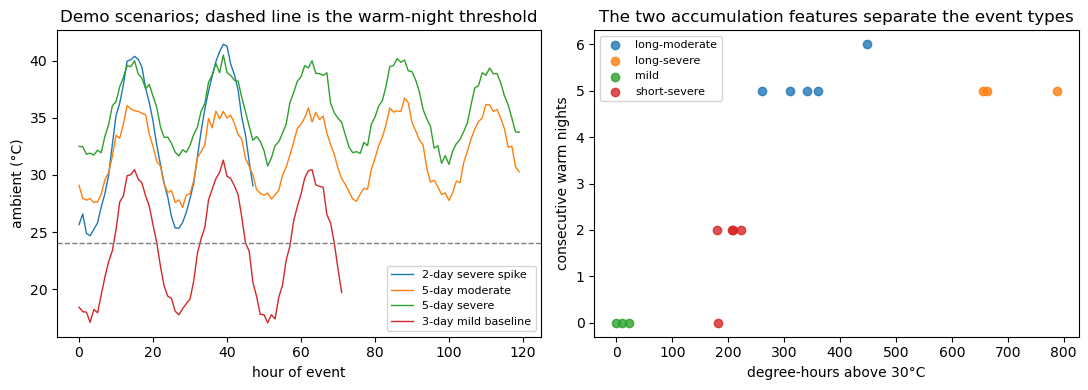

In [8]:
hazard_table = features.build_hazard_table(events, hourly)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for scenario_id, label, *_ in config.SCENARIOS:
    temps = hourly.loc[hourly["event_id"] == scenario_id].sort_values("hour_index")["temp_c"]
    axes[0].plot(range(len(temps)), temps.to_numpy(), label=label, linewidth=1)
axes[0].axhline(config.WARM_NIGHT_C, linestyle="--", color="grey", linewidth=1)
axes[0].set_xlabel("hour of event")
axes[0].set_ylabel("ambient (°C)")
axes[0].set_title("Demo scenarios; dashed line is the warm-night threshold")
axes[0].legend(fontsize=8)

hz = hazard_table.merge(events[["event_id", "event_type", "is_scenario"]], on="event_id")
for event_type, group in hz[~hz["is_scenario"]].groupby("event_type"):
    axes[1].scatter(group["degree_hours_above_30"], group["consecutive_warm_nights"],
                    label=event_type, alpha=0.8)
axes[1].set_xlabel("degree-hours above 30°C")
axes[1].set_ylabel("consecutive warm nights")
axes[1].set_title("The two accumulation features separate the event types")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Feature relationships

Some pairs are collinear by construction and that is expected rather than a
problem at this size: `peak_temp_c` and `max_overnight_min_c` both derive from
the same diurnal curve, and `age_years` and `days_since_maintenance` both track
how long an asset has been neglected. L2 regularisation handles the redundancy;
what matters is that no feature is a proxy for the hidden state, which
`validate.py` checks separately.

`hours_above_35` and `event_duration_days` were deliberately excluded as
collinear with `degree_hours_above_30`.

In [9]:
extractions = extract.load_extractions(inspections)
flags = features.asset_condition_flags(extractions)
pairs, labels, groups = features.training_pairs(outcomes)
X_frame = features.build_feature_matrix(assets, hazard_table, flags, pairs)
X = X_frame.to_numpy()

assert list(X_frame.columns) == config.FEATURES
print(f"feature matrix: {X_frame.shape[0]:,} rows x {X_frame.shape[1]} columns")
X_frame.describe().T[["mean", "std", "min", "max"]].round(3)

feature matrix: 14,400 rows x 15 columns


,mean,std,min,max
peak_temp_c,38.031,3.768,29.952,42.200
degree_hours_above_30,303.449,227.354,0.000,787.220
consecutive_warm_nights,3.062,2.193,0.000,6.000
age_years,32.504,10.683,3.000,57.000
cooling_type_ordinal,0.794,0.759,0.000,2.000
peak_load_pct,0.755,0.113,0.550,0.950
days_since_maintenance,736.242,422.953,1.000,1459.000
prior_heat_faults,0.771,0.872,0.000,4.000
flag_cooling_degraded,0.410,0.492,0.000,1.000
flag_ventilation_obstructed,0.437,0.496,0.000,1.000


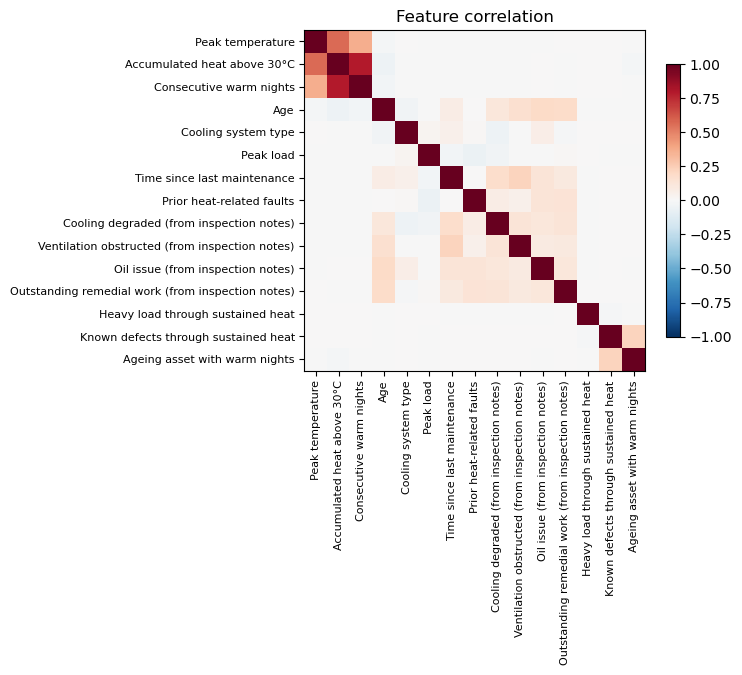

+0.794  degree_hours_above_30 / consecutive_warm_nights
+0.563  peak_temp_c / degree_hours_above_30


In [10]:
corr = X_frame.corr()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
labels_short = [config.FEATURE_LABELS[f] for f in config.FEATURES]
ax.set_xticks(range(len(config.FEATURES)))
ax.set_xticklabels(labels_short, rotation=90, fontsize=8)
ax.set_yticks(range(len(config.FEATURES)))
ax.set_yticklabels(labels_short, fontsize=8)
ax.set_title("Feature correlation")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

pairs_high = [(config.FEATURES[i], config.FEATURES[j], corr.iloc[i, j])
              for i in range(len(config.FEATURES)) for j in range(i + 1, len(config.FEATURES))
              if abs(corr.iloc[i, j]) > 0.5]
for a, b, value in sorted(pairs_high, key=lambda t: -abs(t[2])):
    print(f"{value:+.3f}  {a} / {b}")

## 4. Extraction results

The extraction layer exists for two cases the keyword baseline cannot see: a
defect the note records as *fixed*, and a defect the note explicitly records as
*absent*. Both are false. Overall accuracy hides this, so the error breakdown is
by note category.

The baseline is deliberately naive — per-flag term lists, case-insensitive
substring match, about twenty lines. It is a comparator, not a fallback.

In [11]:
truth = pd.read_csv(config.DATA_DIR / "inspection_truth.csv")
merged, per_flag, by_category = validate.evaluate_extraction(inspections, truth, extractions)

rows = []
for flag, result in per_flag.items():
    rows.append({
        "flag": flag,
        "actual positives": result["llm"]["actual_positive"],
        "LLM precision": result["llm"]["precision"],
        "LLM recall": result["llm"]["recall"],
        "keyword precision": result["baseline"]["precision"],
        "keyword recall": result["baseline"]["recall"],
    })
pd.DataFrame(rows).round(3)

,flag,actual positives,LLM precision,LLM recall,keyword precision,keyword recall
0,cooling_degraded,412,0.957,0.976,0.695,1.000
1,ventilation_obstructed,410,0.856,0.985,0.722,1.000
2,oil_issue,422,0.913,0.964,0.718,0.737
3,overdue_remedial,385,0.837,1.000,0.818,0.855


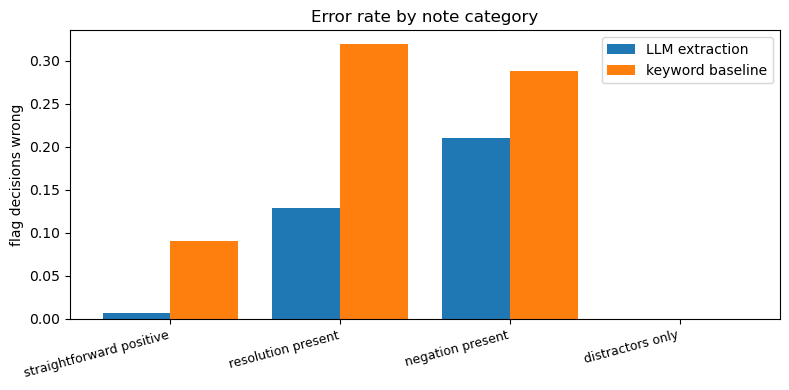

,notes,llm_errors,llm_error_rate,baseline_errors,baseline_error_rate
distractors only,587.0,0.0,0.0000,0.0,0.0000
negation present,146.0,123.0,0.2106,168.0,0.2877
resolution present,159.0,82.0,0.1289,203.0,0.3192
straightforward positive,908.0,26.0,0.0072,330.0,0.0909


In [12]:
category_order = ["straightforward positive", "resolution present",
                  "negation present", "distractors only"]
present = [c for c in category_order if c in by_category]
llm_rates = [by_category[c]["llm_error_rate"] for c in present]
base_rates = [by_category[c]["baseline_error_rate"] for c in present]

x = np.arange(len(present))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, llm_rates, width=0.4, label="LLM extraction")
ax.bar(x + 0.2, base_rates, width=0.4, label="keyword baseline")
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("flag decisions wrong")
ax.set_title("Error rate by note category")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(by_category).T[["notes", "llm_errors", "llm_error_rate",
                             "baseline_errors", "baseline_error_rate"]].round(4)

## 5. Training

Grouped on `event_id`, not on rows. Every asset in one event shares all four
hazard features, so a random split would put the same weather on both sides of
the fold and the reported AUC would be a fiction.

`C` is checked across one decade either side of the default. It is a check, not
a search: the value is not chosen to maximise anything.

In [13]:
predictions = model.out_of_fold_predictions(X, labels, groups)
result = model.evaluate(predictions, labels, groups)
print(f"pooled out-of-fold AUC : {result['auc']:.4f}")
print(f"precision@{config.CREW_CAPACITY}         : {result['precision_at_15']:.4f}")
print(f"recall@{config.CREW_CAPACITY}            : {result['recall_at_15']:.4f}")

pooled out-of-fold AUC : 0.8432
precision@15         : 0.0542
recall@15            : 0.0627


### Pooled AUC is not the operational number

Most pairs in a pooled AUC straddle two different events — a failure in a severe
event against a survivor in a mild one — and separating those needs only "is it
hot for a long time", which requires no model. The number the ranked queue
depends on is the within-event one: given *this* forecast, does the model put the
assets that failed above the ones that did not.

In [14]:
from sklearn.metrics import roc_auc_score

# The mean comes from model.within_event_auc — the same function metrics.md and
# validate.py use. Only the per-event breakdown is computed here, because that is
# a different granularity rather than a second implementation.
mean_within, n_events = model.within_event_auc(predictions, labels, groups)

within = []
for event_id in pd.unique(groups):
    mask = groups == event_id
    if 0 < labels[mask].sum() < mask.sum():
        within.append((event_id, roc_auc_score(labels[mask], predictions[mask]),
                       int(labels[mask].sum())))
within_frame = pd.DataFrame(within, columns=["event_id", "within_event_auc", "failures"])
print(f"events with any failure: {n_events} of {config.N_HISTORICAL_EVENTS}")
print(f"mean within-event AUC  : {mean_within:.4f}")
print("this, not the pooled figure, is the number the crew's decision rests on")
within_frame.sort_values("failures", ascending=False).round(4)


events with any failure: 13 of 16
mean within-event AUC  : 0.6216
this, not the pooled figure, is the number the crew's decision rests on


,event_id,within_event_auc,failures
1,EVT-02,0.8672,43
8,EVT-10,0.7791,27
5,EVT-07,0.7649,24
2,EVT-03,0.8695,12
10,EVT-12,0.6934,8
4,EVT-05,0.6812,6
12,EVT-15,0.3520,5
11,EVT-14,0.4375,4
3,EVT-04,0.6771,3
0,EVT-01,0.0095,2


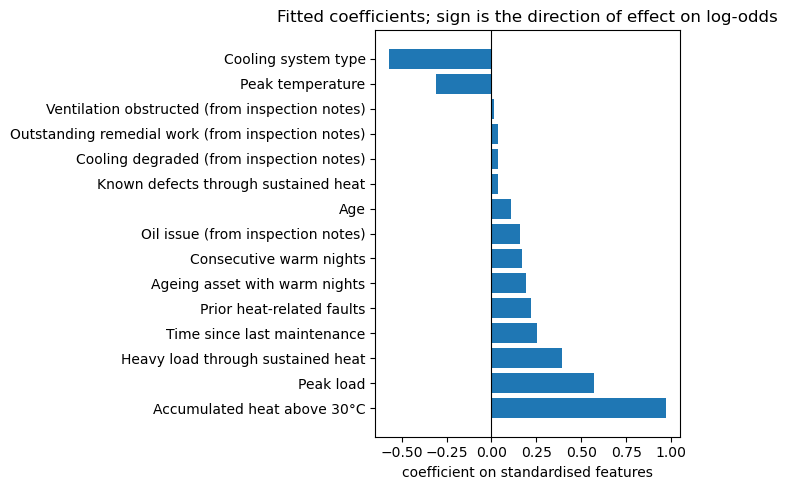

,feature,coefficient
1,Accumulated heat above 30°C,0.9708
5,Peak load,0.5683
12,Heavy load through sustained heat,0.3906
6,Time since last maintenance,0.2506
7,Prior heat-related faults,0.2175
14,Ageing asset with warm nights,0.1919
2,Consecutive warm nights,0.1701
10,Oil issue (from inspection notes),0.1567
3,Age,0.1106
13,Known defects through sustained heat,0.0386


In [15]:
metrics = json.loads((config.OUTPUT_DIR / "metrics.json").read_text())

final = model.build_model()
final.fit(X, labels)
coefficients = pd.DataFrame({
    "feature": [config.FEATURE_LABELS[f] for f in config.FEATURES],
    "coefficient": final["clf"].coef_[0],
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(coefficients["feature"], coefficients["coefficient"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("coefficient on standardised features")
ax.set_title("Fitted coefficients; sign is the direction of effect on log-odds")
plt.tight_layout()
plt.show()
coefficients.round(4)

In [16]:
sweep = pd.DataFrame(metrics["c_sweep"])
print("Regularisation check — recorded, not searched over:")
print(sweep.round(4).to_string(index=False))

Regularisation check — recorded, not searched over:
    C    auc
 0.01 0.8494
 0.10 0.8467
 1.00 0.8432
10.00 0.8424


## 6. Calibration

Calibration is load-bearing here because priority is `risk × customers_served` —
an expected number of customers affected. That only means anything if the
probability means what it says, which is why there is no class weighting, no
resampling and no Platt or isotonic layer on top.

The base rate is synthetic and inflated about twelvefold for trainability
(D-012), so these probabilities are calibrated to the synthetic world, not to
the real one. Ranking is unaffected, and the system consumes a ranking.

The bins are **equal-frequency**, not equal-width. At a 1% base rate equal-width
bins put 98.3% of the rows into the first tenth of the axis and left a single
asset-event as its own point — one transformer the model gave 41%, which did not
fail, drawn as a line collapsing to zero. It read as the model breaking down at
high probability and it was one coin flip (D-042).


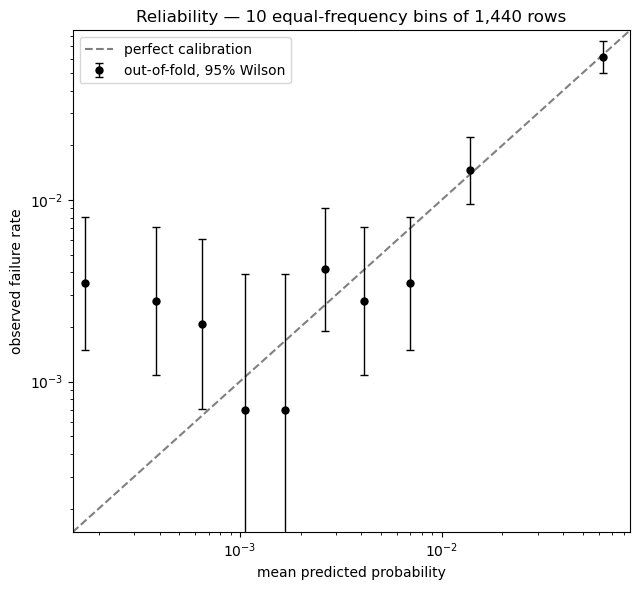

Brier, full model    : 0.00883
Brier, base rate only: 0.00949
improvement          : 0.00066

Only the top two bins carry enough failures to say anything. The eight
below them have intervals wide enough to cover the diagonal several times
over: at ~1,440 rows and a rate near 0.3% that is four failures a bin.


,mean_predicted,observed,count,observed_low,observed_high
0,0.00017,0.00347,1440,0.00148,0.00810
1,0.00039,0.00278,1440,0.00108,0.00712
2,0.00065,0.00208,1440,0.00071,0.00611
3,0.00106,0.00069,1440,0.00012,0.00392
4,0.00168,0.00069,1440,0.00012,0.00392
5,0.00263,0.00417,1440,0.00191,0.00906
6,0.00413,0.00278,1440,0.00108,0.00712
7,0.00694,0.00347,1440,0.00148,0.00810
8,0.01381,0.01458,1440,0.00956,0.02219
9,0.06286,0.06111,1440,0.04987,0.07469


In [17]:
bins = pd.DataFrame(metrics["calibration_bins"])

# Equal-frequency bins, so every point carries the same number of rows and the
# count is not what varies — the width of each bin's Wilson interval is. A point
# off the diagonal but inside its own interval is noise. Log axes because the
# predictions span three orders of magnitude; the diagonal stays straight.
fig, ax = plt.subplots(figsize=(6.5, 6))
edge = min(bins["mean_predicted"].min(), bins.loc[bins["observed"] > 0, "observed"].min()) / 1.15
limit = max(bins["mean_predicted"].max(), bins["observed_high"].max()) * 1.15
ax.plot([edge, limit], [edge, limit], linestyle="--", color="grey", label="perfect calibration")
ax.errorbar(bins["mean_predicted"], bins["observed"],
            yerr=[bins["observed"] - bins["observed_low"],
                  bins["observed_high"] - bins["observed"]],
            fmt="o", color="black", markersize=5, linewidth=1, capsize=3,
            label="out-of-fold, 95% Wilson")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(edge, limit); ax.set_ylim(edge, limit)
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed failure rate")
ax.set_title(f"Reliability — {len(bins)} equal-frequency bins of {bins['count'].iloc[0]:,} rows")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

brier = metrics["brier"]
print(f"Brier, full model    : {brier['model']:.5f}")
print(f"Brier, base rate only: {brier['base_rate']:.5f}")
print(f"improvement          : {brier['improvement']:.5f}")
print()
print("Only the top two bins carry enough failures to say anything. The eight")
print("below them have intervals wide enough to cover the diagonal several times")
print("over: at ~1,440 rows and a rate near 0.3% that is four failures a bin.")
bins.round(5)


## 7. Ablations

Five variants through the same grouped cross-validation loop, arranged as a
ladder so that each rung differs from the full model in exactly one respect.
With only a with-notes/without-notes pair, each arm would differ in two ways at
once and neither the notes nor the interaction terms could be credited
separately.

The variants are defined by **where their information comes from**, not by an
arbitrary feature count. The cell below prints the grouping.


In [18]:
feature_groups = {
    "hazard — from the weather forecast":        config.FEATURES[0:3],
    "asset static — from the register":          config.FEATURES[3:6],
    "condition, structured — also the register": config.FEATURES[6:8],
    "condition, extracted by the LLM from notes": [f"flag_{f}" for f in config.CONDITION_FLAGS],
    "interactions — products of the above":      config.INTERACTION_FEATURES,
}
for name, members in feature_groups.items():
    print(f"{name} ({len(members)})")
    for f in members:
        print(f"    {config.FEATURE_LABELS[f]}")

plain = [f for f in config.FEATURES if f not in config.INTERACTION_FEATURES]
register_only = [f for f in plain if not f.startswith("flag_")]
VARIANTS = {
    "Register only": register_only,
    "Register + notes": plain,
    "Register + interactions (no notes)": config.NO_NOTES_FEATURES,
    "Full model": config.FEATURES,
}
print()
print("'Register only' is a poor label: it includes the forecast. It means")
print("everything available without the LLM reading a single note.")


hazard — from the weather forecast (3)
    Peak temperature
    Accumulated heat above 30°C
    Consecutive warm nights
asset static — from the register (3)
    Age
    Cooling system type
    Peak load
condition, structured — also the register (2)
    Time since last maintenance
    Prior heat-related faults
condition, extracted by the LLM from notes (4)
    Cooling degraded (from inspection notes)
    Ventilation obstructed (from inspection notes)
    Oil issue (from inspection notes)
    Outstanding remedial work (from inspection notes)
interactions — products of the above (3)
    Heavy load through sustained heat
    Known defects through sustained heat
    Ageing asset with warm nights

'Register only' is a poor label: it includes the forecast. It means
everything available without the LLM reading a single note.


In [19]:
ablations = pd.DataFrame(metrics["ablations"]).T
ablations.index.name = "variant"
ablations.round(4)


,n_features,auc,within_event_auc,n_events_scored,precision_at_15,recall_at_15
variant,,,,,,
Heuristic baseline (peak temp x age),2.0,0.6039,0.5487,13.0,0.0042,0.0018
Register only,8.0,0.8480,0.6469,13.0,0.0667,0.0599
Register + notes,12.0,0.8485,0.6605,13.0,0.0458,0.0275
Register + interactions (no notes),10.0,0.8431,0.6107,13.0,0.0625,0.0471
Full model,15.0,0.8432,0.6216,13.0,0.0542,0.0627


### Why does "Register + notes" show *lower* precision and recall than "Register only"?

Adding the LLM-extracted condition flags improves within-event AUC and makes
precision@15 and recall@15 worse. That reads as the extraction layer — the
centrepiece of this build — harming the number the crew cares about, so it
deserves an answer rather than a footnote.

First: are the rates hiding how few events they rest on?


In [20]:
K = config.CREW_CAPACITY
event_ids = np.unique(groups)

def oof(cols):
    return model.out_of_fold_predictions(X_frame[cols].to_numpy(), labels, groups)

def hits_at(scores, k):
    """Failures found in the top k of each event, summed over events."""
    return sum(int(labels[groups == e][np.argsort(-scores[groups == e])[:k]].sum())
               for e in event_ids)

preds = {name: oof(cols) for name, cols in VARIANTS.items()}

print(f"The crew visits {K} assets per event, {len(event_ids)} events "
      f"-> {K * len(event_ids)} visits, against {int(labels.sum())} failures.\n")
for name, scores in preds.items():
    precision, recall = model.precision_recall_at_capacity(scores, labels, groups, K)
    print(f"  {name:36}{hits_at(scores, K):>3} hits   P@{K} {precision:.4f}   R@{K} {recall:.4f}")
print()
print("The whole precision column rests on 11 to 16 hits out of 240. The notes")
print("'costing' precision is a difference of five failures.")


The crew visits 15 assets per event, 16 events -> 240 visits, against 138 failures.

  Register only                        16 hits   P@15 0.0667   R@15 0.0599
  Register + notes                     11 hits   P@15 0.0458   R@15 0.0275
  Register + interactions (no notes)   15 hits   P@15 0.0625   R@15 0.0471
  Full model                           13 hits   P@15 0.0542   R@15 0.0627

The whole precision column rests on 11 to 16 hits out of 240. The notes
'costing' precision is a difference of five failures.


Five out of 240 could easily be noise. The unit of resampling is the **event**,
because that is the unit the metric is averaged over, so a paired bootstrap over
the sixteen events answers it.


In [21]:
rng = np.random.default_rng(config.SEED)

def per_event(scores, metric, k=K):
    out = {}
    for e in event_ids:
        m = groups == e
        if metric == "precision":
            out[e] = labels[m][np.argsort(-scores[m])[:k]].sum() / k
        elif 0 < labels[m].sum() < m.sum():
            out[e] = roc_auc_score(labels[m], scores[m])
    return out

def bootstrap(a, b, draws=4000):
    """Paired difference a - b, resampling whole events with replacement."""
    keys = sorted(set(a) & set(b))
    d = np.array([np.mean([a[k] for k in s]) - np.mean([b[k] for k in s])
                  for s in (rng.choice(keys, size=len(keys), replace=True) for _ in range(draws))])
    return d.mean(), *np.percentile(d, [2.5, 97.5])

for metric in ["precision", "auc"]:
    effect, low, high = bootstrap(per_event(preds["Register + notes"], metric),
                                  per_event(preds["Register only"], metric))
    verdict = "WORSE" if high < 0 else ("BETTER" if low > 0 else "not distinguishable")
    print(f"notes minus register-only, {metric:9}: {effect:+.4f}  "
          f"95% CI [{low:+.4f}, {high:+.4f}]  -> {verdict}")


notes minus register-only, precision: -0.0207  95% CI [-0.0417, -0.0042]  -> WORSE
notes minus register-only, auc      : +0.0135  95% CI [-0.0008, +0.0305]  -> not distinguishable


So the precision drop is **not** noise — the interval sits entirely below zero —
while the AUC gain barely clears it. The one metric the summary tables lead with
for the notes is the weak one.

But "the notes are useless" does not follow. The next cell asks where in the
ranking the harm actually sits.


In [22]:
rows = []
for k in [5, 10, 15, 20, 25, 30, 40, 60, 100, 200, 450]:
    rows.append({"k": k, "visits": k * len(event_ids),
                 "register": hits_at(preds["Register only"], k),
                 "+ notes": hits_at(preds["Register + notes"], k)})
curve = pd.DataFrame(rows).set_index("k")
curve["difference"] = curve["+ notes"] - curve["register"]
print("failures found in the top k, summed over the events\n")
print(curve.to_string())
print()
print("The cost is concentrated between k=15 and k=30 -- the operating range --")
print("and has closed entirely by k=100. AUC integrates over every threshold,")
print("which is why it reports almost nothing either way.")


failures found in the top k, summed over the events

     visits  register  + notes  difference
k                                         
5        80         5        6           1
10      160        11       10          -1
15      240        16       11          -5
20      320        21       18          -3
25      400        25       19          -6
30      480        28       22          -6
40      640        32       30          -2
60      960        43       47           4
100    1600        64       64           0
200    3200        85       85           0
450    7200       116      116           0

The cost is concentrated between k=15 and k=30 -- the operating range --
and has closed entirely by k=100. AUC integrates over every threshold,
which is why it reports almost nothing either way.


Two candidate explanations remain. Either the condition information is worthless
at the top of the ranking, or the notes carry it in a form the model cannot use.

The hidden condition variable settles it. `validate.py` is the only module
allowed to read the generator's hidden state; borrowing it here as a diagnostic
gives the ceiling that no extraction could beat.


In [23]:
hidden = pd.read_csv(config.DATA_DIR / "hidden_asset_state.csv")   # diagnostic only
X_diag = X_frame.assign(
    n_flags=sum(X_frame[f"flag_{f}"] for f in config.CONDITION_FLAGS),
    true_condition=pairs["asset_id"].map(dict(zip(hidden.asset_id, hidden.condition))).to_numpy())

def hits_for(cols):
    return hits_at(model.out_of_fold_predictions(X_diag[cols].to_numpy(), labels, groups), K)

print(f"failures found in the top {K}, of {int(labels.sum())}\n")
for label, cols in [
        ("register only", register_only),
        ("register + 4 separate flags", plain),
        ("register + the flags as ONE count", register_only + ["n_flags"]),
        ("register + the TRUE hidden condition", register_only + ["true_condition"])]:
    print(f"  {label:40}{hits_for(cols):>3}")
print()
print("Condition is not worthless at the top: perfect knowledge of it lifts the")
print("top-15 from 16 to 22. Four binary flags -- a real but noisy version of the")
print("same information -- give 11. Collapsing them to a single count recovers")
print("most of the loss. The failure is in the representation, not the signal.")


failures found in the top 15, of 138

  register only                            16
  register + 4 separate flags              11
  register + the flags as ONE count        13
  register + the TRUE hidden condition     22

Condition is not worthless at the top: perfect knowledge of it lifts the
top-15 from 16 to 22. Four binary flags -- a real but noisy version of the
same information -- give 11. Collapsing them to a single count recovers
most of the loss. The failure is in the representation, not the signal.


### The underlying reason

Logistic regression minimises log-loss across all 14,400 rows. The crew reads the
top 15 of 900, where the average event contains about one failure. A feature that
genuinely improves the average fit — the flags do: they explain 39% of the
variance in hidden condition on their own — can still reallocate confidence in a
way that pushes one or two failures out of a 15-row cut while improving the
middle of the ranking that AUC measures.

**The objective is not the metric.** That is not fixable by more data: the effect
persists in-sample, where there is no generalisation gap, and survives a
thousandfold change in regularisation. What it responds to is representation —
one ordinal count instead of four independent binaries.

The honest summary of this build's extraction layer is therefore narrower than
"the LLM adds value": it reliably recovers condition from free text (precision
0.84–0.96, recall 0.96–1.00 against generation-time truth, section 4), and at
this sample size that recovered condition does not improve crew-level precision,
and as four separate flags it measurably degrades it. See D-025 and the
per-variant capacity sweep in `metrics.md`.


## 8. Error analysis

Two questions. Where did the model rank an asset highly that did not fail, and
where did an asset fail that the model ranked low? Both are expected — failure is
a Bernoulli draw, so a high-risk asset surviving is not a mistake — but the
pattern in them is informative.

In [24]:
analysis = pairs.copy()
analysis["failed"] = labels
analysis["predicted"] = predictions
analysis["event_type"] = analysis["event_id"].map(dict(zip(events["event_id"], events["event_type"])))
analysis["rank_in_event"] = analysis.groupby("event_id")["predicted"].rank(ascending=False)

top_survivors = (analysis[(analysis["rank_in_event"] <= config.CREW_CAPACITY)
                          & (analysis["failed"] == 0)]
                 .sort_values("predicted", ascending=False).head(10))
print("Highest-risk assets that did not fail:")
print(top_survivors[["asset_id", "event_id", "event_type", "predicted", "rank_in_event"]]
      .round(4).to_string(index=False))

Highest-risk assets that did not fail:
   asset_id event_id  event_type  predicted  rank_in_event
SUB-SGW-493   EVT-10 long-severe     0.4114            1.0
SUB-SGW-822   EVT-02 long-severe     0.3303            1.0
SUB-SGW-696   EVT-02 long-severe     0.3267            2.0
SUB-SGW-839   EVT-02 long-severe     0.3094            4.0
SUB-SGW-288   EVT-10 long-severe     0.3094            2.0
SUB-SGW-625   EVT-02 long-severe     0.3049            5.0
SUB-SGW-717   EVT-02 long-severe     0.2639            8.0
SUB-SGW-373   EVT-02 long-severe     0.2631            9.0
SUB-SGW-138   EVT-02 long-severe     0.2585           10.0
SUB-SGW-213   EVT-02 long-severe     0.2535           11.0


In [25]:
missed = (analysis[analysis["failed"] == 1]
          .sort_values("rank_in_event", ascending=False).head(10))
print("Failures the model ranked lowest within their event:")
print(missed[["asset_id", "event_id", "event_type", "predicted", "rank_in_event"]]
      .round(4).to_string(index=False))

Failures the model ranked lowest within their event:
   asset_id event_id    event_type  predicted  rank_in_event
SUB-SGW-867   EVT-05 long-moderate     0.0001          899.0
SUB-SGW-423   EVT-01          mild     0.0000          897.0
SUB-SGW-843   EVT-01          mild     0.0001          885.0
SUB-SGW-488   EVT-10   long-severe     0.0006          874.0
SUB-SGW-650   EVT-04  short-severe     0.0002          840.0
SUB-SGW-759   EVT-15 long-moderate     0.0006          826.0
SUB-SGW-287   EVT-07   long-severe     0.0040          806.0
SUB-SGW-800   EVT-15 long-moderate     0.0006          800.0
SUB-SGW-600   EVT-11          mild     0.0001          776.0
SUB-SGW-074   EVT-10   long-severe     0.0024          730.0


In [26]:
# What separates a missed failure from a caught one? Compare the flags and the
# register fields, using only what the model could see.
caught = analysis[(analysis["failed"] == 1) & (analysis["rank_in_event"] <= config.CREW_CAPACITY)]
missed_all = analysis[(analysis["failed"] == 1) & (analysis["rank_in_event"] > config.CREW_CAPACITY)]

comparison = []
for name, subset in [("caught in top 15", caught), ("missed", missed_all)]:
    rows = X_frame.loc[subset.index]
    comparison.append({
        "group": name,
        "n": len(subset),
        **{config.FEATURE_LABELS[f]: rows[f].mean() for f in
           ["age_years", "peak_load_pct", "days_since_maintenance", "prior_heat_faults",
            "flag_cooling_degraded", "flag_oil_issue"]},
    })
pd.DataFrame(comparison).set_index("group").round(3).T

group,caught in top 15,missed
n,13.000,125.000
Age,38.692,34.176
Peak load,0.916,0.835
Time since last maintenance,959.692,838.168
Prior heat-related faults,2.077,0.816
Cooling degraded (from inspection notes),0.615,0.480
Oil issue (from inspection notes),0.769,0.512


Missed failures are the ones with no recorded defect and an unremarkable
register entry — nothing the model could have read told it they were at risk.
That is the honest ceiling on this design: it ranks recorded condition against
forecast stress, and an asset whose condition was never recorded is invisible to
it. Continuous telemetry would be the thing that catches those, and it is listed
as a deliberate exclusion rather than an oversight.